In [1673]:
!pip install streamlit

In [1674]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st

In [1675]:
!ls ./drive/MyDrive/data/C*.csv

./drive/MyDrive/data/California_Houses.csv  ./drive/MyDrive/data/CCTV_Seoul.csv


In [1676]:
df = pd.read_csv('./drive/MyDrive/data/California_Houses.csv')

In [1677]:
df.head()

,Median_House_Value,Median_Income,Median_Age,Tot_Rooms,Tot_Bedrooms,Population,Households,Latitude,Longitude,Distance_to_coast,Distance_to_LA,Distance_to_SanDiego,Distance_to_SanJose,Distance_to_SanFrancisco
0,452600.0,8.3252,41,880,129,322,126,37.88,-122.23,9263.040773,556529.158342,735501.806984,67432.517001,21250.213767
1,358500.0,8.3014,21,7099,1106,2401,1138,37.86,-122.22,10225.733072,554279.850069,733236.884360,65049.908574,20880.600400
2,352100.0,7.2574,52,1467,190,496,177,37.85,-122.24,8259.085109,554610.717069,733525.682937,64867.289833,18811.487450
3,341300.0,5.6431,52,1274,235,558,219,37.85,-122.25,7768.086571,555194.266086,734095.290744,65287.138412,18031.047568
4,342200.0,3.8462,52,1627,280,565,259,37.85,-122.25,7768.086571,555194.266086,734095.290744,65287.138412,18031.047568


In [1678]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Median_House_Value        20640 non-null  float64
 1   Median_Income             20640 non-null  float64
 2   Median_Age                20640 non-null  int64  
 3   Tot_Rooms                 20640 non-null  int64  
 4   Tot_Bedrooms              20640 non-null  int64  
 5   Population                20640 non-null  int64  
 6   Households                20640 non-null  int64  
 7   Latitude                  20640 non-null  float64
 8   Longitude                 20640 non-null  float64
 9   Distance_to_coast         20640 non-null  float64
 10  Distance_to_LA            20640 non-null  float64
 11  Distance_to_SanDiego      20640 non-null  float64
 12  Distance_to_SanJose       20640 non-null  float64
 13  Distance_to_SanFrancisco  20640 non-null  float64
dtypes: flo

In [1679]:
df.isna().sum().sum() # nan 확인

np.int64(0)

In [1680]:
target = df.Median_House_Value
data = df.iloc[:, 1:]

In [1681]:
target

,Median_House_Value
0,452600.0
1,358500.0
2,352100.0
3,341300.0
4,342200.0
...,...
20635,78100.0
20636,77100.0
20637,92300.0
20638,84700.0


In [1682]:
data

,Median_Income,Median_Age,Tot_Rooms,Tot_Bedrooms,Population,Households,Latitude,Longitude,Distance_to_coast,Distance_to_LA,Distance_to_SanDiego,Distance_to_SanJose,Distance_to_SanFrancisco
0,8.3252,41,880,129,322,126,37.88,-122.23,9263.040773,556529.158342,735501.806984,67432.517001,21250.213767
1,8.3014,21,7099,1106,2401,1138,37.86,-122.22,10225.733072,554279.850069,733236.884360,65049.908574,20880.600400
2,7.2574,52,1467,190,496,177,37.85,-122.24,8259.085109,554610.717069,733525.682937,64867.289833,18811.487450
3,5.6431,52,1274,235,558,219,37.85,-122.25,7768.086571,555194.266086,734095.290744,65287.138412,18031.047568
4,3.8462,52,1627,280,565,259,37.85,-122.25,7768.086571,555194.266086,734095.290744,65287.138412,18031.047568
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,1.5603,25,1665,374,845,330,39.48,-121.09,162031.481121,654530.186299,830631.543047,248510.058162,222619.890417
20636,2.5568,18,697,150,356,114,39.49,-121.21,160445.433537,659747.068444,836245.915229,246849.888948,218314.424634
20637,1.7000,17,2254,485,1007,433,39.43,-121.22,153754.341182,654042.214020,830699.573163,240172.220489,212097.936232
20638,1.8672,18,1860,409,741,349,39.43,-121.32,152005.022239,657698.007703,834672.461887,238193.865909,207923.199166


In [1683]:
from sklearn.model_selection import train_test_split

In [1684]:
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=1)
# train은 훈련데이터들
# test는 시험데이터
# 훈련할때는 test 데이터로 훈련을 하지 않는다.

In [1685]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape # shape로 데이터 갯수가 같은지 확인하기

((16512, 13), (16512,), (4128, 13), (4128,))

프로그램 방식의 전환

과거

데이터 , 규칙 -> 전통적인 프로그램 -> 정답

현재

데이터, 정답 -> 머신러닝 -> 규칙

In [1686]:
from sklearn.linear_model import LinearRegression

In [1687]:
lr = LinearRegression().fit(X_train, y_train) # x데이터와 y정답데이터를 이용해서 계수를 구하는 코드

In [1688]:
lr.coef_, lr.intercept_

(array([ 3.97044994e+04,  9.10028125e+02, -6.49648589e+00,  1.12193974e+02,
        -3.89573411e+01,  3.81194362e+01, -4.47693447e+04, -2.83448038e+04,
        -2.28137733e-01, -1.41022108e-01,  2.34815691e-01,  1.56701004e-01,
        -1.30899835e-01]),
 np.float64(-1823591.661396965))

In [1689]:
lr.score(X_train, y_train) #R^2

0.6479433856586778

In [1690]:
lr.score(X_test, y_test)

0.6398759616415535

In [1691]:
def Regression_process(x, y):
    X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)
    lr = LinearRegression().fit(X_train, y_train)
    print('R square (train set, test set)', np.round(lr.score(X_train, y_train), 4), np.round(lr.score(X_test, y_test), 4))

In [1692]:
# 데이터 정제 => 집값과 상관 없는거 제외
x = data.drop(['Latitude', 'Longitude'], axis=1)
y = target

In [1693]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Median_Income             20640 non-null  float64
 1   Median_Age                20640 non-null  int64  
 2   Tot_Rooms                 20640 non-null  int64  
 3   Tot_Bedrooms              20640 non-null  int64  
 4   Population                20640 non-null  int64  
 5   Households                20640 non-null  int64  
 6   Distance_to_coast         20640 non-null  float64
 7   Distance_to_LA            20640 non-null  float64
 8   Distance_to_SanDiego      20640 non-null  float64
 9   Distance_to_SanJose       20640 non-null  float64
 10  Distance_to_SanFrancisco  20640 non-null  float64
dtypes: float64(6), int64(5)
memory usage: 1.7 MB


In [1694]:
# 만든 학습 모델에 넣기
Regression_process(x, y)

R square (train set, test set) 0.6367 0.63


In [1695]:
x.Median_Age.value_counts().shape[0] # 구현한 값들의 갯수

52

In [1696]:
df_1 = pd.DataFrame(index=['Unique_count'])
for i in x.columns:
    df_1[i] = [x.loc[:, i:].value_counts().shape[0]]

In [1697]:
df_1.T

,Unique_count
Median_Income,20640
Median_Age,20640
Tot_Rooms,20640
Tot_Bedrooms,20640
Population,20640
Households,20611
Distance_to_coast,12590
Distance_to_LA,12590
Distance_to_SanDiego,12590
Distance_to_SanJose,12590


In [1698]:
y

,Median_House_Value
0,452600.0
1,358500.0
2,352100.0
3,341300.0
4,342200.0
...,...
20635,78100.0
20636,77100.0
20637,92300.0
20638,84700.0


In [1699]:
import matplotlib.style as style
style.use('ggplot')
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import norm
from scipy import stats

sns.set_style("whitegrid")

def visualize_target(y):
    fig = plt.figure(constrained_layout=True, figsize=(12,6))
    grid = gridspec.GridSpec(ncols=5, nrows=5, figure=fig)

    ax1 = fig.add_subplot(grid[0:2, :4])
    ax1.set_title('Histogram')
    sns.distplot(y, norm_hist=True,fit=norm, ax = ax1,color='indianred')

    ax2 = fig.add_subplot(grid[2:, :4])
    ax2.set_title('QQ_plot')
    stats.probplot(y, plot = ax2)

    ax3 = fig.add_subplot(grid[:, 4])
    ax3.set_title('Box Plot')
    sns.boxplot(y=y, orient='v', ax = ax3,color='indianred')

/tmp/ipykernel_44922/197922672.py:16: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y, norm_hist=True,fit=norm, ax = ax1,color='indianred')


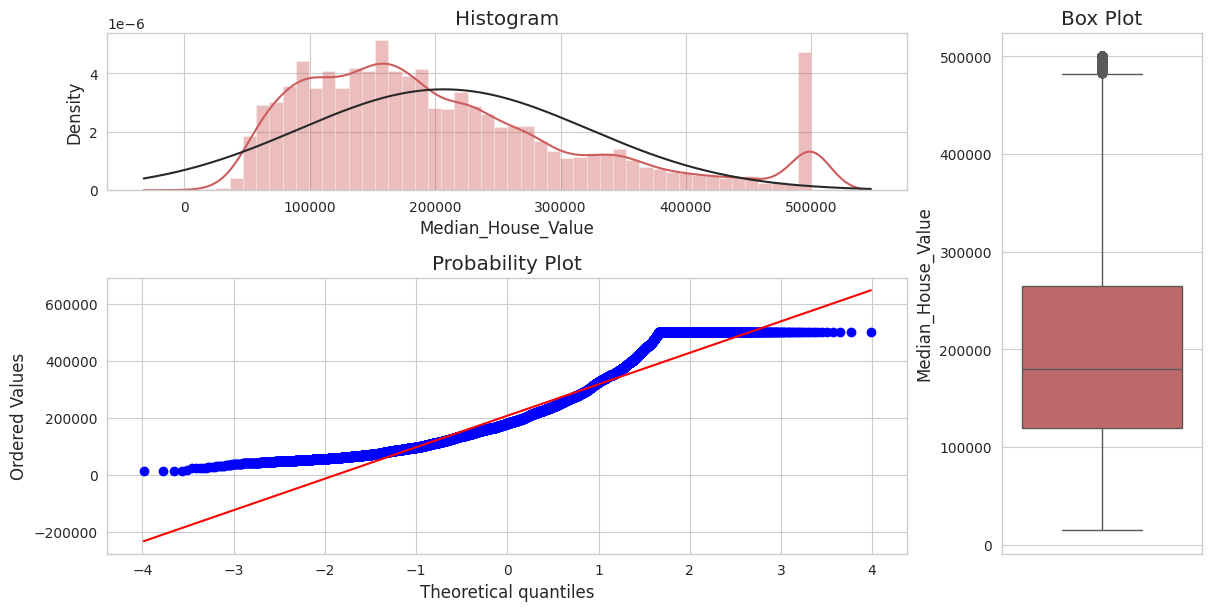

In [1700]:
visualize_target(y=y)

In [1701]:
def rm_outlier(x, y):
    q1 = y.quantile(0.25)
    q3 = y.quantile(0.75)
    iqr = q3 - q1
    outlier = []
    for i in y:
        if i < (q1 - 1.5 * iqr) or i > (q3 + 1.5 * iqr):
            outlier.append(i)
    outlier = pd.DataFrame(outlier, columns=['outlier'])
    print('There is {}% Outlier removed in {} according to IQR rule'.format(
        round((outlier.shape[0]/y.shape[0])*100,2),y.name)
    )
    fence_low = q1 - 1.5 * iqr
    fence_high = q3 + 1.5 * iqr
    x = x[(y > fence_low) & (y < fence_high)]
    y = y[(y > fence_low) & (y < fence_high)]
    return x, y

In [1702]:
x, y = rm_outlier(x, y)

There is 5.19% Outlier removed in Median_House_Value according to IQR rule


In [1703]:
Regression_process(x, y)

R square (train set, test set) 0.6029 0.5939


/tmp/ipykernel_44922/197922672.py:16: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y, norm_hist=True,fit=norm, ax = ax1,color='indianred')


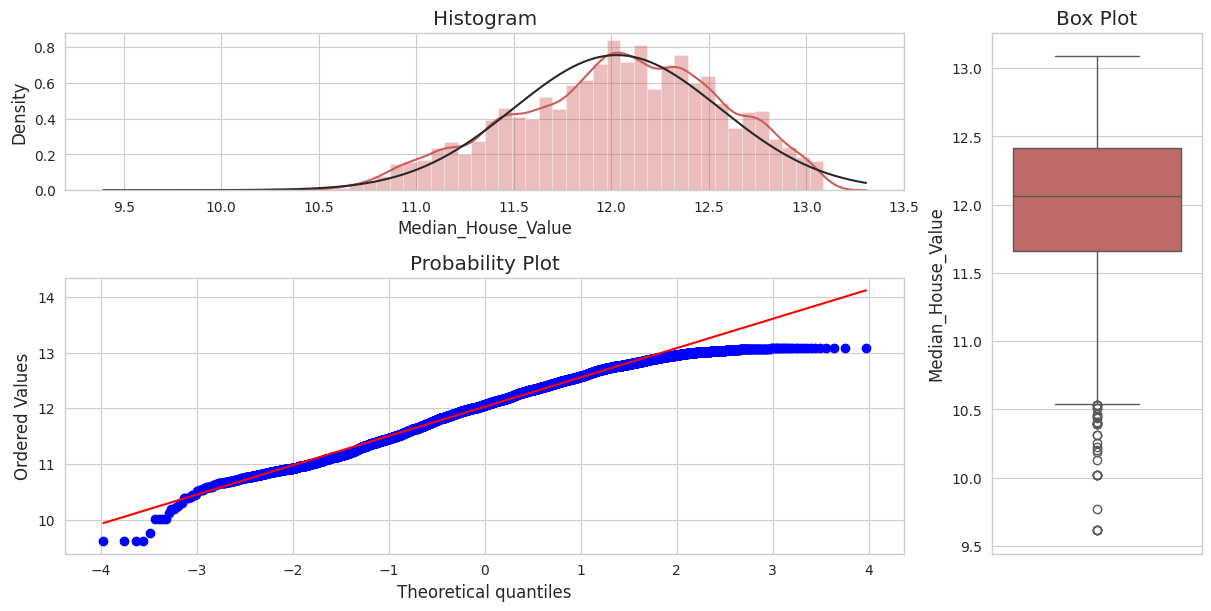

In [1704]:
y = np.log1p(y)
visualize_target(y)

In [1705]:
xs = 80
log1p_x = np.log1p(xs)

In [1706]:
log1p_x

np.float64(4.394449154672439)

In [1707]:
np.expm1(log1p_x)

np.float64(80.00000000000003)

# 결측자료 대체

특성변수의 평균, 중위수, 최빈수, 내삽

SimpleImputer 라이브러리 사용

In [1708]:
x_miss = np.array([[1, 2, 3, None],
                   [5, np.nan, 7, 8],
                   [None, 10, 11, 12],
                   [13, np.nan, 15, 16]]
)

In [1709]:
x_miss

array([[1, 2, 3, None],
       [5, nan, 7, 8],
       [None, 10, 11, 12],
       [13, nan, 15, 16]], dtype=object)

In [1710]:
from sklearn.impute import SimpleImputer

In [1711]:
# 평균
im = SimpleImputer(strategy='mean')
im.fit_transform(x_miss)

array([[ 1.        ,  2.        ,  3.        , 12.        ],
       [ 5.        ,  6.        ,  7.        ,  8.        ],
       [ 6.33333333, 10.        , 11.        , 12.        ],
       [13.        ,  6.        , 15.        , 16.        ]])

In [1712]:
# 중앙값
im = SimpleImputer(strategy='median')
im.fit_transform(x_miss)

array([[ 1.,  2.,  3., 12.],
       [ 5.,  6.,  7.,  8.],
       [ 5., 10., 11., 12.],
       [13.,  6., 15., 16.]])

In [1713]:
im = SimpleImputer(strategy='most_frequent')
im.fit_transform(np.array([[1, 2, 3, np.nan],
                            [5, np.nan, 7, 8],
                            [np.nan, 10, 11, 12],
                            [13, np.nan, 15, 16]]))

array([[ 1.,  2.,  3.,  8.],
       [ 5.,  2.,  7.,  8.],
       [ 1., 10., 11., 12.],
       [13.,  2., 15., 16.]])

In [1714]:
!ls ./drive/MyDrive/data/temperature_ts_data

./drive/MyDrive/data/temperature_ts_data


In [1715]:
data = pd.read_csv('./drive/MyDrive/data/temperature_ts_data',
                 parse_dates=[0],
                 index_col=[0])

In [1716]:
data

,temperature
timestamp,
2014-01-01 00:00:00,4.519298
2014-01-01 01:00:00,3.915000
2014-01-01 02:00:00,3.626667
2014-01-01 03:00:00,3.446667
2014-01-01 04:00:00,3.191667
...,...
2014-12-31 19:00:00,-2.916667
2014-12-31 20:00:00,-3.626667
2014-12-31 21:00:00,-3.953333


In [1717]:
data[data.isnull().temperature]

,temperature
timestamp,
2014-01-01 19:00:00,NaN
2014-01-02 05:00:00,NaN
2014-01-02 06:00:00,NaN
2014-01-02 07:00:00,NaN
2014-01-02 08:00:00,NaN
...,...
2014-12-18 05:00:00,NaN
2014-12-18 06:00:00,NaN
2014-12-18 07:00:00,NaN


In [1718]:
data

,temperature
timestamp,
2014-01-01 00:00:00,4.519298
2014-01-01 01:00:00,3.915000
2014-01-01 02:00:00,3.626667
2014-01-01 03:00:00,3.446667
2014-01-01 04:00:00,3.191667
...,...
2014-12-31 19:00:00,-2.916667
2014-12-31 20:00:00,-3.626667
2014-12-31 21:00:00,-3.953333


In [1719]:
# agg 집계함수
diurnal_data = data.dropna().resample('D').agg(['mean', 'size'])

In [1720]:
diurnal_data

temperature     
                  mean size
timestamp                  
2014-01-01    5.418464   23
2014-01-02    2.757333    5
2014-01-03         NaN    0
2014-01-04    2.196111    9
2014-01-05    0.746597   24
...                ...  ...
2014-12-27   -1.083194   24
2014-12-28   -0.439861   24
2014-12-29    3.284931   24
2014-12-30    3.472292   24
2014-12-31   -0.550000   24

[365 rows x 2 columns]

In [1721]:
diurnal_data.loc[diurnal_data.temperature['size'] < 19, ('temperature', 'mean')] = np.nan

In [1722]:
diurnal_data.head()

temperature     
                  mean size
timestamp                  
2014-01-01    5.418464   23
2014-01-02         NaN    5
2014-01-03         NaN    0
2014-01-04         NaN    9
2014-01-05    0.746597   24

Text(0, 0.5, 'Temperature (C)')

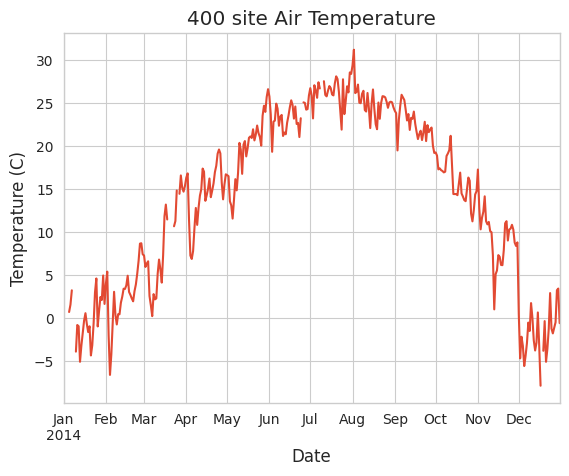

In [1723]:
fig = diurnal_data.loc[:, ('temperature', 'mean')].plot()
fig.set_title('400 site Air Temperature')
fig.set_xlabel('Date')
fig.set_ylabel('Temperature (C)')

In [1724]:
df = diurnal_data.temperature['mean'].iloc[:120]

In [1725]:
df

,mean
timestamp,
2014-01-01,5.418464
2014-01-02,NaN
2014-01-03,NaN
2014-01-04,NaN
2014-01-05,0.746597
...,...
2014-04-26,19.178403
2014-04-27,15.826944
2014-04-28,13.839792


Text(0, 0.5, 'Temperature (C)')

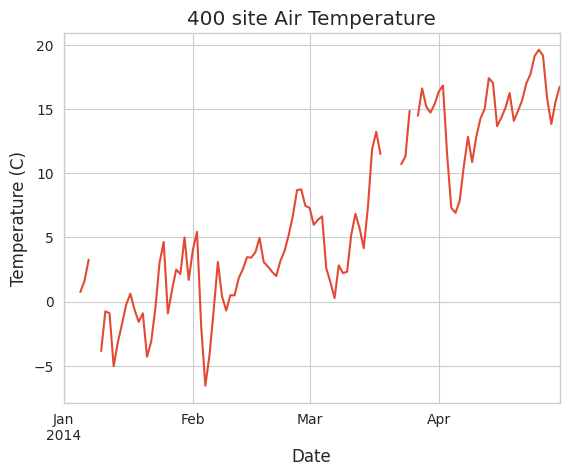

In [1726]:
fig = df.plot()
fig.set_title('400 site Air Temperature')
fig.set_xlabel('Date')
fig.set_ylabel('Temperature (C)')

In [1727]:
methods = ['linear', 'quadratic', 'cubic']

In [1728]:
df_gapfilled = pd.DataFrame({m: df.interpolate(method=m) for m in methods})

Text(0, 0.5, 'Temperature (C)')

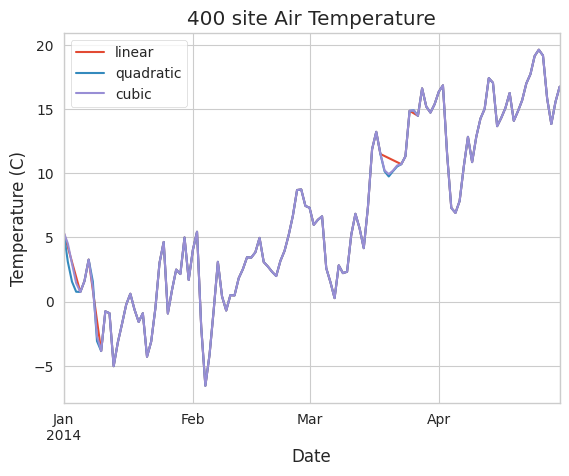

In [1729]:
fig = df_gapfilled.plot()
fig.set_title('400 site Air Temperature')
fig.set_xlabel('Date')
fig.set_ylabel('Temperature (C)')

In [1730]:
df_gapfilled

,linear,quadratic,cubic
timestamp,,,
2014-01-01,5.418464,5.418464,5.418464
2014-01-02,4.250497,3.101056,4.529056
2014-01-03,3.082531,1.549943,2.956273
2014-01-04,1.914564,0.765123,1.446620
2014-01-05,0.746597,0.746597,0.746597
...,...,...,...
2014-04-26,19.178403,19.178403,19.178403
2014-04-27,15.826944,15.826944,15.826944
2014-04-28,13.839792,13.839792,13.839792


# 시계열 분석

- QC 단계
    1. 결측 검사: 기온 결측 자료는 np.nan으로 채워 넣는다.
    2. 물리 한계 검사
    3. 단계 검사: [현재기온 - 1분전 기온]을 사용, 현재 기온을 오류 처리
    4. 지속성 검사: 단계검사에서 산출한 값의 절대값을 사용하여 시간별로 60개씩 합한 값을 구한다. 합계 한 값이 0.1보다 작으면 60개 전부 오류 처리
    5. 오류는 모두 np.nan을 의미

(자료가 80% 이하 일때는 결측처리)

매시간 평균, 3시간 평균, 8시간 평균, 일평균 산출

각각 그래프 추가 => Streamlit으로 표현

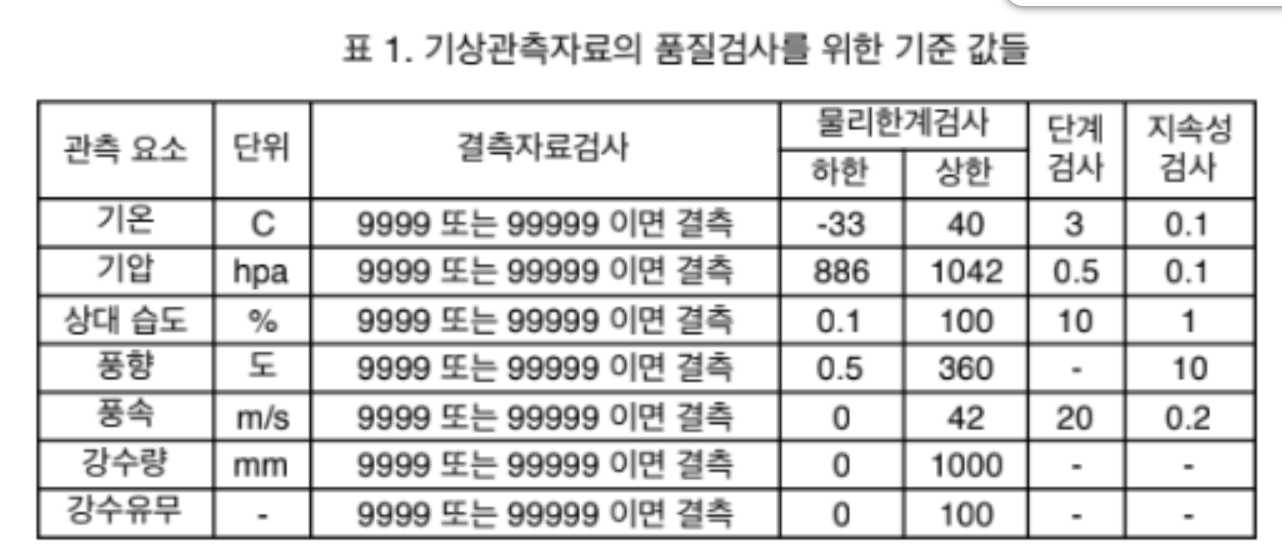

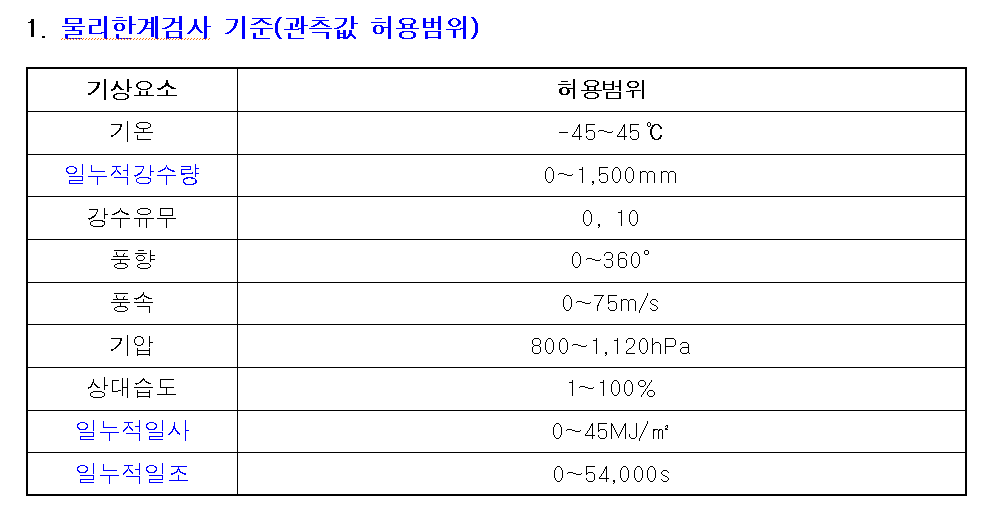

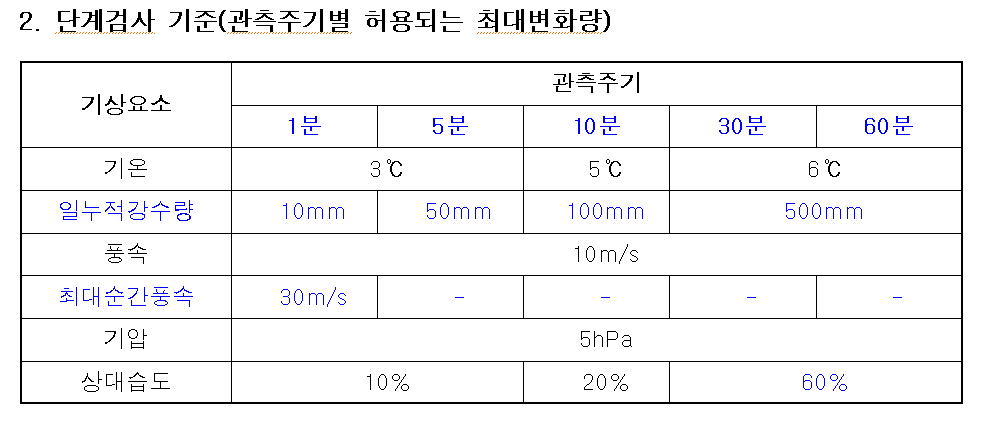

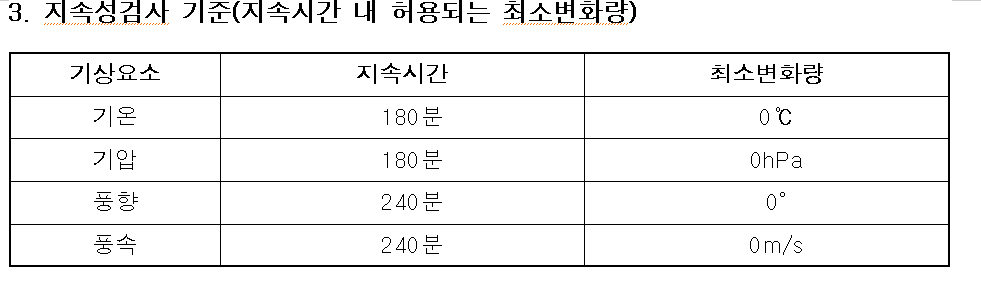

In [1731]:
!ls ./drive/MyDrive/data/OBS*.csv

./drive/MyDrive/data/OBS_ASOS_MI_20260427131717.csv
./drive/MyDrive/data/OBS_ASOS_MI_20260427134032.csv
./drive/MyDrive/data/OBS_ASOS_MI_20260427134118.csv
./drive/MyDrive/data/OBS_ASOS_MI_20260427134141.csv
./drive/MyDrive/data/OBS_ASOS_MI_20260427134204.csv


In [1732]:
df_0419 = pd.read_csv('./drive/MyDrive/data/OBS_ASOS_MI_20260427131717.csv', encoding='cp949', parse_dates=[0], index_col=[2])
df_0420 = pd.read_csv('./drive/MyDrive/data/OBS_ASOS_MI_20260427134032.csv', encoding='cp949', parse_dates=[0], index_col=[2])
df_0421 = pd.read_csv('./drive/MyDrive/data/OBS_ASOS_MI_20260427134118.csv', encoding='cp949', parse_dates=[0], index_col=[2])
df_0422 = pd.read_csv('./drive/MyDrive/data/OBS_ASOS_MI_20260427134141.csv', encoding='cp949', parse_dates=[0], index_col=[2])
df_0423 = pd.read_csv('./drive/MyDrive/data/OBS_ASOS_MI_20260427134204.csv', encoding='cp949', parse_dates=[0], index_col=[2])

In [1733]:
df_0419.head()

,지점,지점명,기온(°C)
일시,,,
2026-04-19 00:01,108,서울,17.7
2026-04-19 00:02,108,서울,17.6
2026-04-19 00:03,108,서울,17.6
2026-04-19 00:04,108,서울,17.6
2026-04-19 00:05,108,서울,17.6


In [1734]:
df_0419.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1440 entries, 2026-04-19 00:01 to 2026-04-20 00:00
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   지점      1440 non-null   object 
 1   지점명     1440 non-null   object 
 2   기온(°C)  1440 non-null   float64
dtypes: float64(1), object(2)
memory usage: 45.0+ KB


In [1735]:
df_0419.isna().sum().sum()

np.int64(0)

In [1736]:
df_0419.index

Index(['2026-04-19 00:01', '2026-04-19 00:02', '2026-04-19 00:03',
       '2026-04-19 00:04', '2026-04-19 00:05', '2026-04-19 00:06',
       '2026-04-19 00:07', '2026-04-19 00:08', '2026-04-19 00:09',
       '2026-04-19 00:10',
       ...
       '2026-04-19 23:51', '2026-04-19 23:52', '2026-04-19 23:53',
       '2026-04-19 23:54', '2026-04-19 23:55', '2026-04-19 23:56',
       '2026-04-19 23:57', '2026-04-19 23:58', '2026-04-19 23:59',
       '2026-04-20 00:00'],
      dtype='object', name='일시', length=1440)

In [1737]:
df_0420.head()

,지점,지점명,기온(°C)
일시,,,
2026-04-20 00:01,108,서울,17.8
2026-04-20 00:02,108,서울,17.8
2026-04-20 00:03,108,서울,17.8
2026-04-20 00:04,108,서울,17.7
2026-04-20 00:05,108,서울,17.7


In [1738]:
df_0420.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1440 entries, 2026-04-20 00:01 to 2026-04-21 00:00
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   지점      1440 non-null   object 
 1   지점명     1440 non-null   object 
 2   기온(°C)  1440 non-null   float64
dtypes: float64(1), object(2)
memory usage: 45.0+ KB


In [1739]:
df_0421.head()

,지점,지점명,기온(°C)
일시,,,
2026-04-21 00:01,108,서울,9.1
2026-04-21 00:02,108,서울,9.1
2026-04-21 00:03,108,서울,9.1
2026-04-21 00:04,108,서울,9.1
2026-04-21 00:05,108,서울,9.1


In [1740]:
df_0421.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1440 entries, 2026-04-21 00:01 to 2026-04-22 00:00
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   지점      1440 non-null   object 
 1   지점명     1440 non-null   object 
 2   기온(°C)  1440 non-null   float64
dtypes: float64(1), object(2)
memory usage: 45.0+ KB


In [1741]:
df_0422.head()

,지점,지점명,기온(°C)
일시,,,
2026-04-22 00:01,108,서울,10.8
2026-04-22 00:02,108,서울,10.8
2026-04-22 00:03,108,서울,10.8
2026-04-22 00:04,108,서울,10.8
2026-04-22 00:05,108,서울,10.8


In [1742]:
df_0422.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1440 entries, 2026-04-22 00:01 to 2026-04-23 00:00
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   지점      1440 non-null   object 
 1   지점명     1440 non-null   object 
 2   기온(°C)  1440 non-null   float64
dtypes: float64(1), object(2)
memory usage: 45.0+ KB


In [1743]:
df_0423.head()

,지점,지점명,기온(°C)
일시,,,
2026-04-23 00:01,108,서울,12.4
2026-04-23 00:02,108,서울,12.4
2026-04-23 00:03,108,서울,12.4
2026-04-23 00:04,108,서울,12.4
2026-04-23 00:05,108,서울,12.3


In [1744]:
df_0423.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1440 entries, 2026-04-23 00:01 to 2026-04-24 00:00
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   지점      1440 non-null   object 
 1   지점명     1440 non-null   object 
 2   기온(°C)  1440 non-null   float64
dtypes: float64(1), object(2)
memory usage: 45.0+ KB


In [1745]:
df = pd.concat([df_0419, df_0420, df_0421, df_0422, df_0423])

In [1746]:
df

,지점,지점명,기온(°C)
일시,,,
2026-04-19 00:01,108,서울,17.7
2026-04-19 00:02,108,서울,17.6
2026-04-19 00:03,108,서울,17.6
2026-04-19 00:04,108,서울,17.6
2026-04-19 00:05,108,서울,17.6
...,...,...,...
2026-04-23 23:56,108,서울,14.2
2026-04-23 23:57,108,서울,14.2
2026-04-23 23:58,108,서울,14.2


In [1747]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7200 entries, 2026-04-19 00:01 to 2026-04-24 00:00
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   지점      7200 non-null   object 
 1   지점명     7200 non-null   object 
 2   기온(°C)  7200 non-null   float64
dtypes: float64(1), object(2)
memory usage: 225.0+ KB


In [1748]:
df

,지점,지점명,기온(°C)
일시,,,
2026-04-19 00:01,108,서울,17.7
2026-04-19 00:02,108,서울,17.6
2026-04-19 00:03,108,서울,17.6
2026-04-19 00:04,108,서울,17.6
2026-04-19 00:05,108,서울,17.6
...,...,...,...
2026-04-23 23:56,108,서울,14.2
2026-04-23 23:57,108,서울,14.2
2026-04-23 23:58,108,서울,14.2


In [1749]:
df.columns

Index(['지점', '지점명', '기온(°C)'], dtype='object')

In [1750]:
df.rename(columns={'지점':'location', '지점명':'name', '기온(°C)':'celsius'}, inplace=True)

In [1751]:
df.loc[(df.celsius < -45) | (df.celsius > 45), 'celsius'] = np.nan

In [1752]:
df.drop(columns='location', inplace=True)

In [1754]:
df.index

Index(['2026-04-19 00:01', '2026-04-19 00:02', '2026-04-19 00:03',
       '2026-04-19 00:04', '2026-04-19 00:05', '2026-04-19 00:06',
       '2026-04-19 00:07', '2026-04-19 00:08', '2026-04-19 00:09',
       '2026-04-19 00:10',
       ...
       '2026-04-23 23:51', '2026-04-23 23:52', '2026-04-23 23:53',
       '2026-04-23 23:54', '2026-04-23 23:55', '2026-04-23 23:56',
       '2026-04-23 23:57', '2026-04-23 23:58', '2026-04-23 23:59',
       '2026-04-24 00:00'],
      dtype='object', name='일시', length=7200)

In [1755]:
df.index = pd.to_datetime(df.index)

In [1756]:
df_hour = df.dropna().resample('h').agg({'name':'first', 'celsius':'mean'})
df_3hour = df.dropna().resample('3h').agg({'name':'first', 'celsius':'mean'})
df_8hour = df.dropna().resample('8h').agg({'name':'first', 'celsius':'mean'})
df_day = df.dropna().resample('d').agg({'name':'first', 'celsius':'mean'})

In [1757]:
df_hour

,name,celsius
일시,,
2026-04-19 00:00:00,서울,17.377966
2026-04-19 01:00:00,서울,16.978333
2026-04-19 02:00:00,서울,16.595000
2026-04-19 03:00:00,서울,15.995000
2026-04-19 04:00:00,서울,15.481667
...,...,...
2026-04-23 20:00:00,서울,18.311667
2026-04-23 21:00:00,서울,17.110000
2026-04-23 22:00:00,서울,15.893333


Text(0, 0.5, 'Temperature (C)')

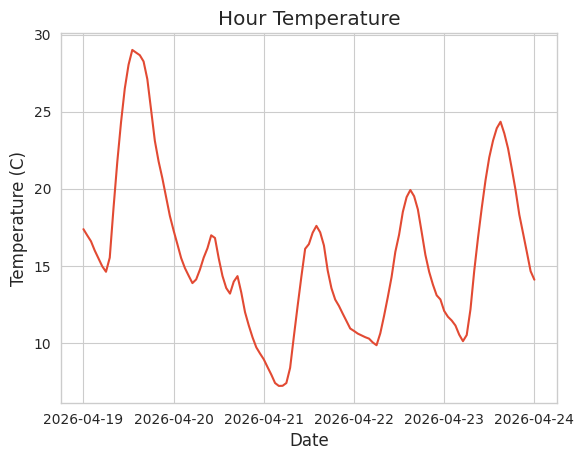

In [1758]:
fig, ax = plt.subplots()
ax.plot(df_hour.index, df_hour['celsius'])
ax.set_title('Hour Temperature')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (C)')

Text(0, 0.5, 'Temperature (C)')

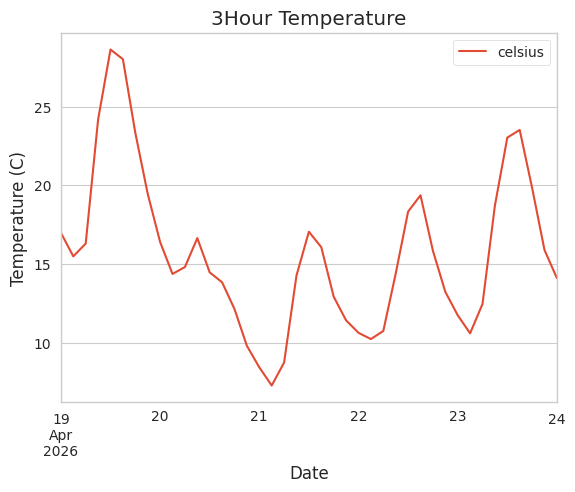

In [1759]:
fig = df_3hour.plot()
fig.set_title('3Hour Temperature')
fig.set_xlabel('Date')
fig.set_ylabel('Temperature (C)')

Text(0, 0.5, 'Temperature (C)')

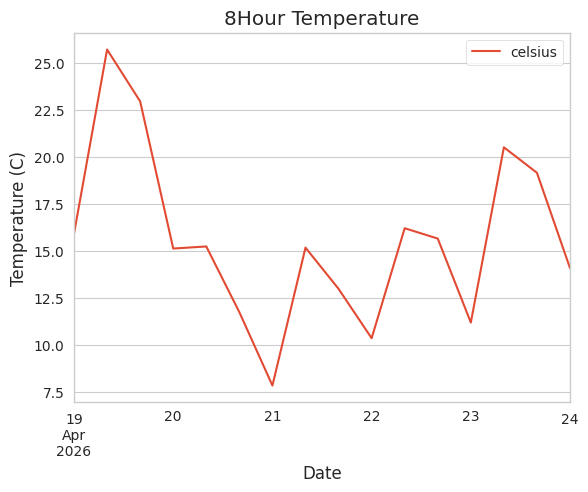

In [1760]:
fig = df_8hour.plot()
fig.set_title('8Hour Temperature')
fig.set_xlabel('Date')
fig.set_ylabel('Temperature (C)')

Text(0, 0.5, 'Temperature (C)')

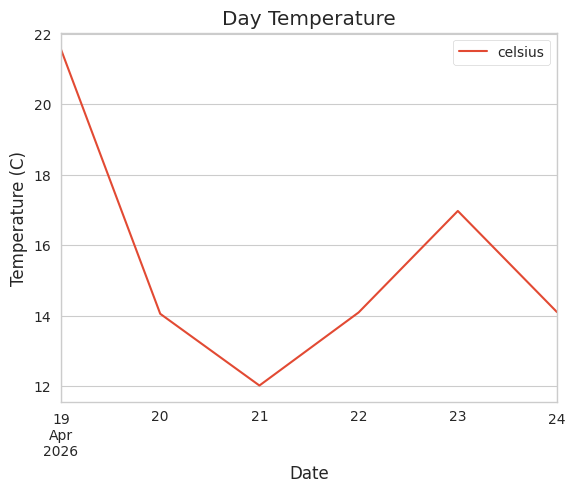

In [1761]:
fig = df_day.plot()
fig.set_title('Day Temperature')
fig.set_xlabel('Date')
fig.set_ylabel('Temperature (C)')